In [ ]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving new_dataset.xlsx to new_dataset.xlsx


In [ ]:
df = pd.read_excel("new_dataset.xlsx")
df.head()


,Project_Name,Ticket_Type,Priority,Created_Date,Resolution_Date,Resolution_Details,Status,Resolution_Time,Priority_Score,Response_Efficiency
0,d1z0,Ticket,Medium,2016-01-06 08:23:43,2016-01-06 08:56:55,Done,done,0.55,3,5.45
1,d1z0,Ticket,Medium,2016-01-11 10:06:19,2016-01-12 12:30:23,Done,done,26.40,3,0.11
2,d1z0,Ticket,Medium,2016-01-21 07:28:20,2016-01-26 08:21:47,Done,done,120.89,3,0.02
3,d1z0,Vacation,Medium,2016-01-26 07:44:54,2016-01-26 07:45:48,Done,done,0.02,3,150.00
4,d1z0,Story,Medium,2016-02-01 13:45:47,2016-02-07 06:21:42,Done,done,136.60,3,0.02


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90963 entries, 0 to 90962
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Project_Name         90963 non-null  object        
 1   Ticket_Type          90963 non-null  object        
 2   Priority             90963 non-null  object        
 3   Created_Date         90963 non-null  datetime64[ns]
 4   Resolution_Date      89518 non-null  datetime64[ns]
 5   Resolution_Details   89518 non-null  object        
 6   Status               90963 non-null  object        
 7   Resolution_Time      89518 non-null  float64       
 8   Priority_Score       90963 non-null  int64         
 9   Response_Efficiency  89518 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 6.9+ MB


In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['Project_Name', 'Ticket_Type', 'Priority', 'Created_Date',
       'Resolution_Date', 'Resolution_Details', 'Status', 'Resolution_Time',
       'Priority_Score', 'Response_Efficiency'],
      dtype='object')

In [ ]:
# 2. Drop unnecessary empty columns
cols_to_drop = [
    'Customer Email',
    'Ticket Status',
    'Resolution',
    'Customer Satisfaction Rating',
    'Unnamed: 9'
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

In [ ]:
df['Resolution_Details'] = df['Resolution_Details'].fillna('Pending/Under Review')

In [ ]:
df['Created_Date'] = pd.to_datetime(df['Created_Date'], errors='coerce')
df['Resolution_Date'] = pd.to_datetime(df['Resolution_Date'], errors='coerce')

In [ ]:
df['Resolution_Duration_Hours'] = (
    df['Resolution_Date'] - df['Created_Date']
).dt.total_seconds() / 3600

In [ ]:
priority_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4
}

df['Priority_Score'] = df['Priority'].map(priority_map)

In [ ]:
df['Response_Efficiency'] = df['Priority_Score'] / df['Resolution_Duration_Hours']

In [ ]:
df.head()

,Project_Name,Ticket_Type,Priority,Created_Date,Resolution_Date,Resolution_Details,Status,Resolution_Time,Priority_Score,Response_Efficiency,Resolution_Duration_Hours
0,d1z0,Ticket,Medium,2016-01-06 08:23:43,2016-01-06 08:56:55,Done,done,0.55,2.0,3.614458,0.553333
1,d1z0,Ticket,Medium,2016-01-11 10:06:19,2016-01-12 12:30:23,Done,done,26.40,2.0,0.075754,26.401111
2,d1z0,Ticket,Medium,2016-01-21 07:28:20,2016-01-26 08:21:47,Done,done,120.89,2.0,0.016544,120.890833
3,d1z0,Vacation,Medium,2016-01-26 07:44:54,2016-01-26 07:45:48,Done,done,0.02,2.0,133.333333,0.015000
4,d1z0,Story,Medium,2016-02-01 13:45:47,2016-02-07 06:21:42,Done,done,136.60,2.0,0.014641,136.598611


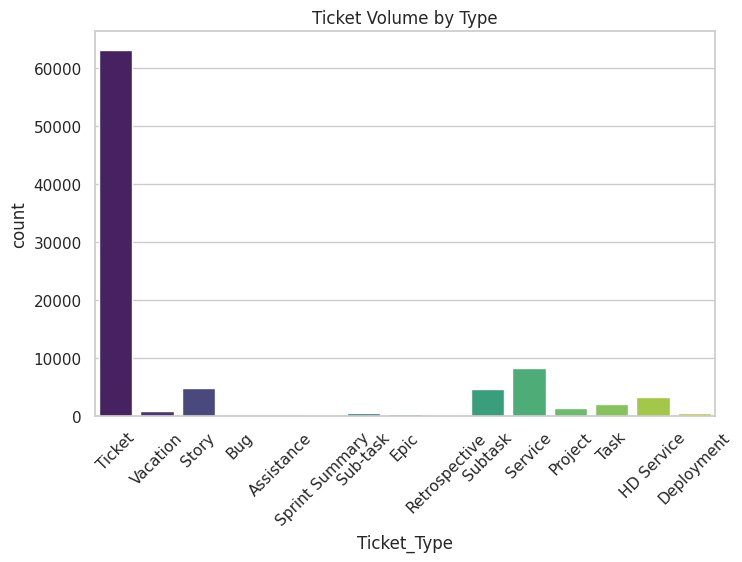

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='Ticket_Type',
    hue='Ticket_Type',
    palette='viridis',
    legend=False
)
plt.title("Ticket Volume by Type")
plt.xticks(rotation=45)
plt.show()

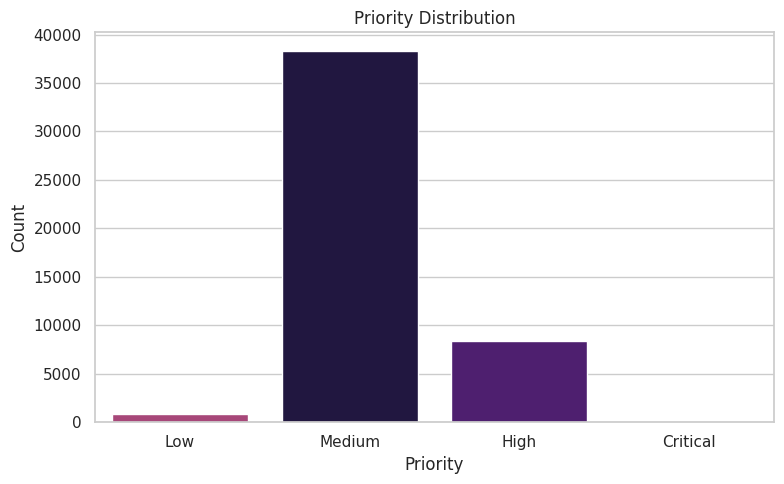

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Priority',
    hue='Priority',
    order=['Low','Medium','High','Critical'],
    palette='magma',
    legend=False
)

plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

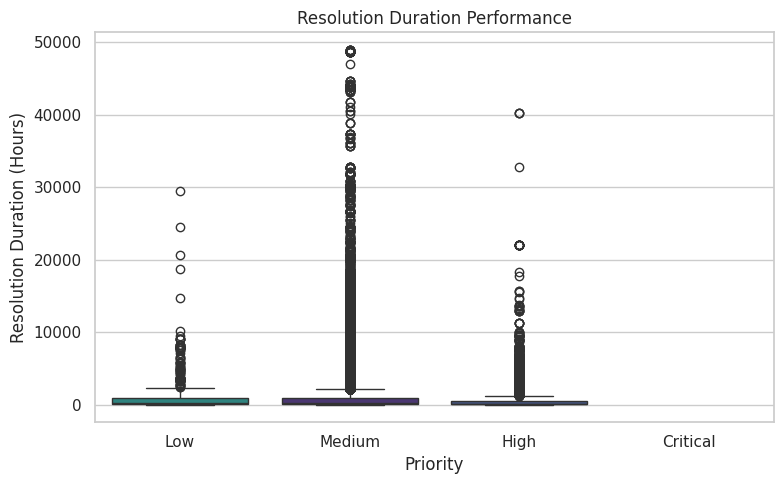

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Priority',
    y='Resolution_Duration_Hours',
    hue='Priority',
    order=['Low','Medium','High','Critical'],
    palette='viridis',
    legend=False
)

plt.title("Resolution Duration Performance")
plt.xlabel("Priority")
plt.ylabel("Resolution Duration (Hours)")
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("Cleaned_Project_Data.csv", index=False)

In [ ]:
df.to_excel("Cleaned_Project_Data.xlsx", index=False)